<h1><u><center>MSIN0097 Predictive Analytics- Individual Coursework</center></u></h1>
<h1><center> Credit Default Prediction </center></h1>

### Candidate No. VTVS0

## Project Overview
**Introduction:**
Credit default prediction plays a critical role in retail credit risk management (Markov, Seleznyova and Lapshin, 2022). Rising default rates can erode portfolio profitability and threaten financial stability (Avery, Calem and Canner, 2004; Aarfi, Ahmed and Syed, 2024). 

Prior research shows that machine learning models can effectively identify high-risk cardholders and support targeted interventions to reduce expected losses (Yeh and Lien, 2009; Aarfi, Ahmed and Syed, 2024). However, regulators increasingly require credit scoring models to be not only accurate, but also transparent and auditable (Bücker et al., 2020).

Motivated by these considerations, this project develops a predictive model to estimate the probability of default in the next month for credit card clients.  

**Project Goal:** Build a model to estimate next-month default risk for credit card clients using an auditable workflow with agent collaboration. The model serves as a short-term monitoring tool to flag clients with elevated risk.

**Source of data:** UCI / Kaggle “Default of Credit Card Clients”   
URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset?resource=download

## Table of Content

- [Section 1. Obtain a Dataset and Frame the Predictive Problem](#section-1-obtain-a-dataset-and-frame-the-predictive-problem)
  - [1.1 Load Dataset](#11-load-dataset)
  - [1.2 Define Target Variable and Prediction Type](#12-define-target-variable-and-prediction-type)
  - [1.3 Define Success Metrics and Constraints](#13-define-success-metrics-and-constraints)
  - [1.4 Assumptions and Limitations](#14-assumptions-and-limitations)
  - [1.5 Agent Touchpoint: Metric Selection](#15-agent-touchpoint-metric-selection)

- [Section 2. Explore the Data to Gain Insights](#section-2-explore-the-data-to-gain-insights)
  - [2.1 Target Distribution and Class Imbalance](#21-target-distribution-and-class-imbalance)
    - [2.1.1 Default Rate by Selected Predictors](#211-default-rate-by-selected-predictors)
  - [2.2 Missingness and Data Quality](#22-missingness-and-data-quality)
    - [2.2.1 Missing Value Check](#221-missing-value-check)
    - [2.2.2 Categorical Variable Inspection](#222-categorical-variable-inspection)
    - [2.2.3 Negative Billing Amount Investigation](#223-negative-billing-amount-investigation)
  - [2.3 Correlation and Leakage Risk](#23-correlation-and-leakage-risk)
  - [2.4 Outlier Inspection](#24-outlier-inspection)
  - [2.5 Key EDA Observations](#25-key-eda-observations)
  - [2.6 Agent Touchpoint: EDA Validation](#26-agent-touchpoint-eda-validation)

- [Section 3. Prepare the Data](#section-3-prepare-the-data)
  - [3.1 Agent Touchpoint: Cleaning / Split Verification](#31-agent-touchpoint-cleaning--split-verification)
  - [3.2 Train/Test Split Discipline](#32-traintest-split-discipline)
  - [3.3 Preprocessing Pipeline](#33-preprocessing-pipeline)
  - [3.4 Data Validation Checks](#34-data-validation-checks)

- [Section 4. Explore Different Models and Shortlist the Best Ones](#section-4-explore-different-models-and-shortlist-the-best-ones)
  - [4.1 Agent Touchpoint: Model Suggestion & Verification](#41-agent-touchpoint-model-suggestion--verification)
  - [4.2 Baseline Model — Logistic Regression](#42-baseline-model--logistic-regression)
  - [4.3 Modern Model — Random Forest](#43-modern-model--random-forest)
  - [4.4 Model Comparison and Shortlisting Decision](#44-model-comparison-and-shortlisting-decision)

- [Section 5. Fine-Tune and Evaluate](#section-5-fine-tune-and-evaluate)
  - [5.1 Hyperparameter Tuning Strategy](#51-hyperparameter-tuning-strategy)
  - [5.2 Final Test Set Evaluation](#52-final-test-set-evaluation)
  - [5.3 Threshold and Error Analysis](#53-threshold-and-error-analysis)
  - [5.4 Model Understanding and Calibration](#54-model-understanding-and-calibration)
    - [5.4.1 Feature Importance](#541-feature-importance)
    - [5.4.2 Calibration](#542-calibration)
  - [5.5 Agent Touchpoint: Explicit Agent-Made Mistake and Correction](#55-agent-touchpoint-explicit-agent-made-mistake-and-correction)

- [Section 6. Present the Final Solution](#section-6-present-the-final-solution)
  - [6.1 Final Model and Rationale](#61-final-model-and-rationale)
  - [6.2 Limitations, Risks and Next Steps](#62-limitations-risks-and-next-steps)
  - [6.3 Model Card Summary](#63-model-card-summary)  

- [Section 7. Reference](#section-7-reference)

- [Appendix A. Agent Usage & Decision Register](#appendix-a-agent-usage-log--decision-register)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Model & evaluation libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, average_precision_score, classification_report, precision_recall_curve, roc_curve, auc, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.calibration import calibration_curve

## Section 1. Obtain Dataset & Frame the Predictive Problem

### 1.1 Load Dataset

The dataset used in this project is the “Default of Credit Card Clients” dataset (UCI Machine Learning Repository / Kaggle version), containing 30,000 observations and 25 variables.

The data were collected from credit card clients in Taiwan between April 2005 and September 2005.

Each row represents an individual client.

Variables can be grouped into following categories:  
- **Demographic variables**: SEX, EDUCATION, MARRIAGE, AGE
- **Credit limit**: LIMIT_BAL
- **Repayment status variables (PAY_0 to PAY_6)**: Monthly delinquency indicators over the previous six months, where higher values indicate longer payment delays.
- **Billing amounts (BILL_AMT1 to BILL_AMT6)**: Monthly statement amounts over the previous six months.
- **Payment amounts (PAY_AMT1 to PAY_AMT6)**: Monthly repayment amounts over the previous six months.
- **default.payment.next.month**: indicating whether the client defaulted in the following month.

In [2]:
# Define project paths
project_root = Path("..")  # assuming notebook is inside /notebooks
data_path = project_root / "data" / "credit_default.csv"

# Load dataset
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 1.2 Define Target Variable and Prediction Type

The target variable is `default.payment.next.month`, which indicates whether a client will default in the following month (1 = default, 0 = no default).   

This is a binary classification problem. The objective is to predict whether a credit card client will default in the following month.  

From a business perspective, this problem supports credit risk management by identifying higher-risk clients in advance.

In [3]:
# Set the target variable
target_column = "default.payment.next.month"

### 1.3 Define Success Metrics and Constraints

The dataset exhibits class imbalance (~22% default rate), making accuracy inappropriate as a primary metric.

#### Primary Metric: ROC-AUC

ROC-AUC is selected as the primary evaluation metric because:

- Credit risk modelling is fundamentally a ranking problem.
- ROC-AUC evaluates how well higher-risk clients are ranked above lower-risk clients across all possible thresholds.
- It is widely adopted in credit scoring practice. (Denis, no date)
#### Complementary Diagnostics

- AUPRC (Area Under the Precision-Recall Curve)
- Recall
- Confusion matrix analysis

#### Constraints

- The test set must be strictly held out before model selection and hyperparameter tuning.
- Stratified splitting must be used to preserve class distribution.
- Evaluation must remain threshold-independent until final decision analysis.

Additional practical constraints include:
- Interpretability considerations, as credit risk models may be subject to regulatory scrutiny.
- Stability across time, given potential distribution shifts in economic conditions.
- Fairness considerations, particularly with respect to demographic variables such as SEX and EDUCATION.

In [4]:
# Check class imbalance
class_distribution = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index()
)

class_distribution

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [5]:
# Majority-class baseline accuracy
baseline_accuracy = class_distribution.loc[0]

print(f"If predicting all clients as non-default, accuracy = {baseline_accuracy:.2%}")

If predicting all clients as non-default, accuracy = 77.88%


### 1.4 Assumptions and Limitations

**Assumptions**

- Historical repayment behaviour predicts next-month default.
- The dataset represents the broader credit card client population.
- The distribution of features remains similar between the training and test sets.
- All features are measured correctly and do not contain systematic recording errors.
- All variables are available at the time of scoring. This means that no feature includes information that would only be known after the prediction decision.

**Limitations**

- The dataset is based on credit card clients in Taiwan and may not generalise to other regions.
- The data does not include macroeconomic variables or external credit bureau information.
- The dataset reflects historical conditions and may not capture structural economic changes.


### 1.5 Agent Touchpoint: Metric Selection  

To validate the evaluation strategy, an AI agent (Claude Code) was consulted.

**Prompt to Claude Code:**

> I am working on a binary classification problem (credit default prediction) with approximately 22% positive class representation.  
> I have initially selected ROC-AUC as the primary evaluation metric.  
> Please evaluate whether ROC-AUC is appropriate and discuss trade-offs compared to AUPRC and accuracy.

### Agent Feedback (Summary)

The agent suggested that:

- AUPRC may be more informative under class imbalance, as it focuses on minority-class performance.  
- Accuracy may be misleading in imbalanced settings.  

### Evaluation and Decision  

- **Use ROC-AUC as the primary metric — Retained.**  
   This decision was made because the dataset reflects moderate rather than severe imbalance (~22%), and the modelling objective prioritises ranking quality. ROC-AUC evaluates how effectively higher-risk clients are ranked above lower-risk clients across all thresholds, which aligns with credit risk practice. (Denis, no date)

- **Use AUPRC — Partially adopted.**  
   While AUPRC emphasises minority-class performance, it was incorporated as a complementary diagnostic metric rather than replacing ROC-AUC. This allows additional insight into performance under imbalance without shifting the primary evaluation objective.

- **Use accuracy — Rejected**  
   Agree with the agent’s reasoning that it can obscure minority-class performance when classes are unevenly distributed.

## Section 2. Explore the Data to Gain Insights

### 2.1 Target Distribution and Class Imbalance

Before model development, the distribution of the target variable is examined to confirm class imbalance and support the metric selection discussed in Section 1.

,count,proportion
default.payment.next.month,,
0,23364,0.7788
1,6636,0.2212


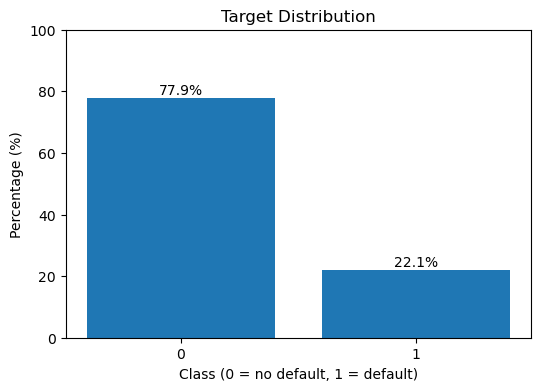

In [6]:
# Compute class counts and proportions (to assess imbalance)
class_counts = df[target_column].value_counts().sort_index()
class_proportions = df[target_column].value_counts(normalize=True).sort_index()

# Display summary table
display(pd.DataFrame({
    "count": class_counts,
    "proportion": class_proportions
}))

# Plot percentage distribution of target variable
plt.figure(figsize=(6,4))
bars = plt.bar(class_proportions.index.astype(str),
               class_proportions.values * 100)

plt.title("Target Distribution")
plt.xlabel("Class (0 = no default, 1 = default)")
plt.ylabel("Percentage (%)")
plt.ylim(0,100)

# Annotate bars with percentage values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.1f}%",
             ha='center',
             va='bottom')

plt.show()

The distribution confirms that approximately 22% of clients default. 
This moderate class imbalance justifies avoiding accuracy as a primary evaluation metric.

#### 2.1.1 Default Rate by Selected Predictors

To assess discriminatory power, default rates are examined across selected variables.

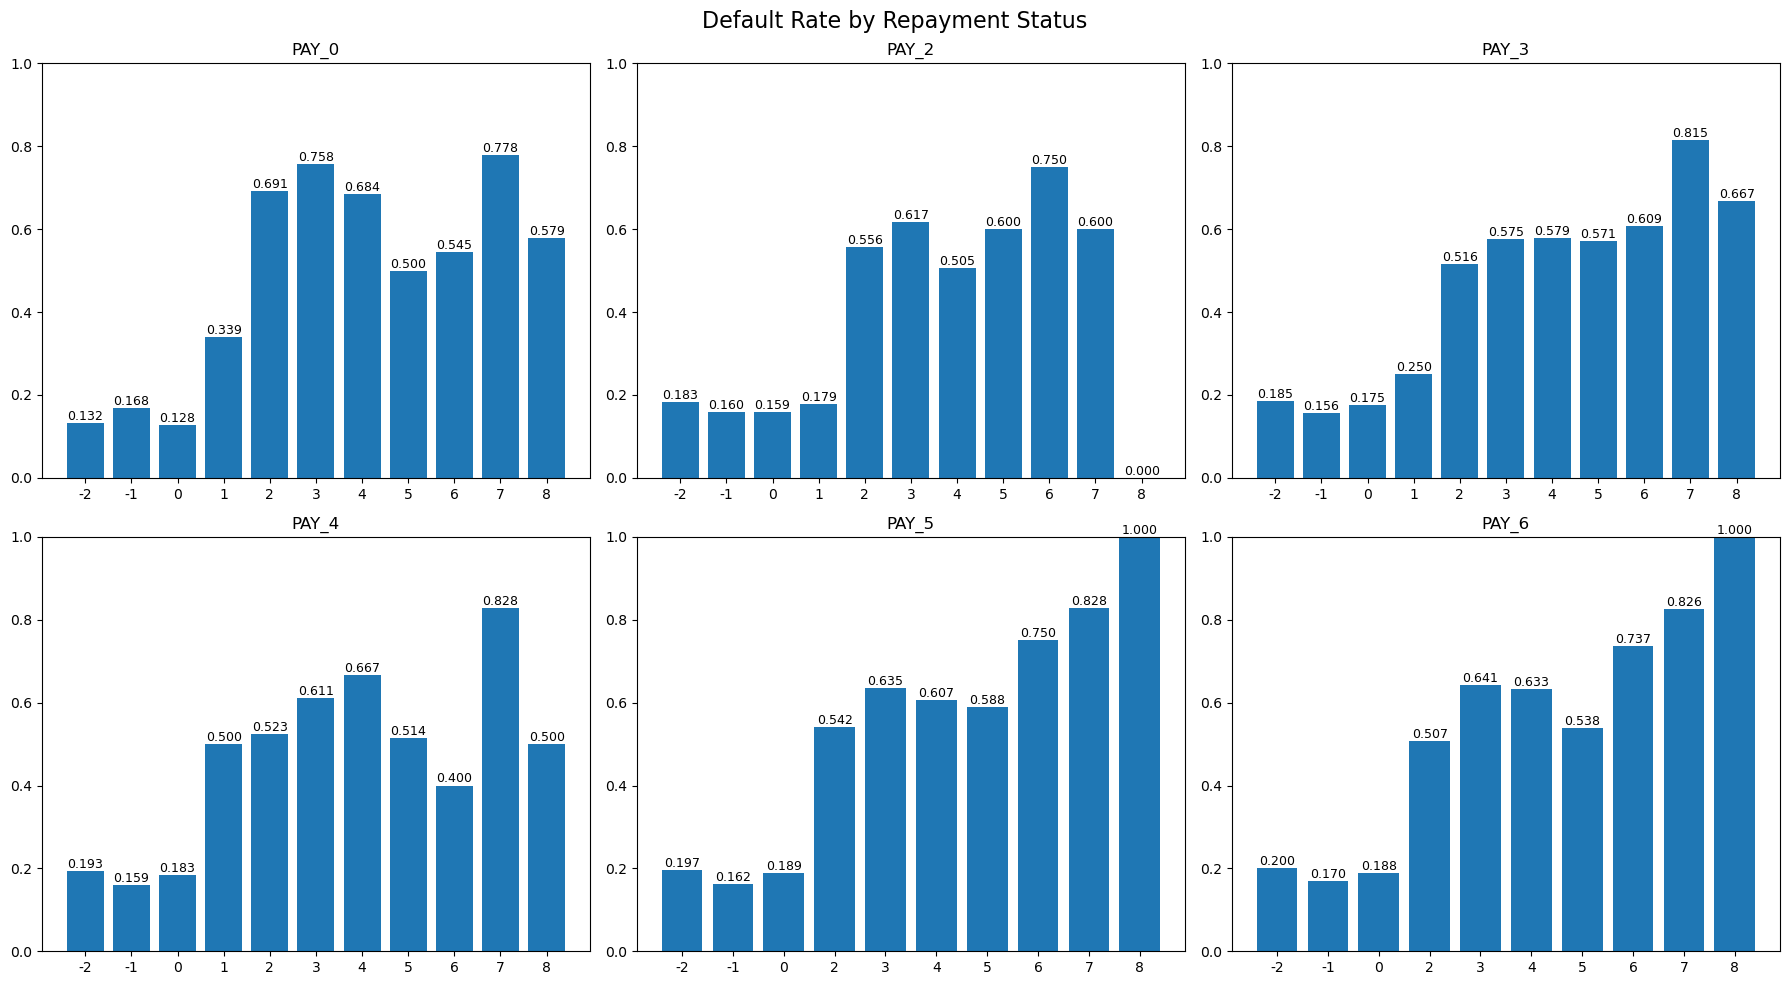

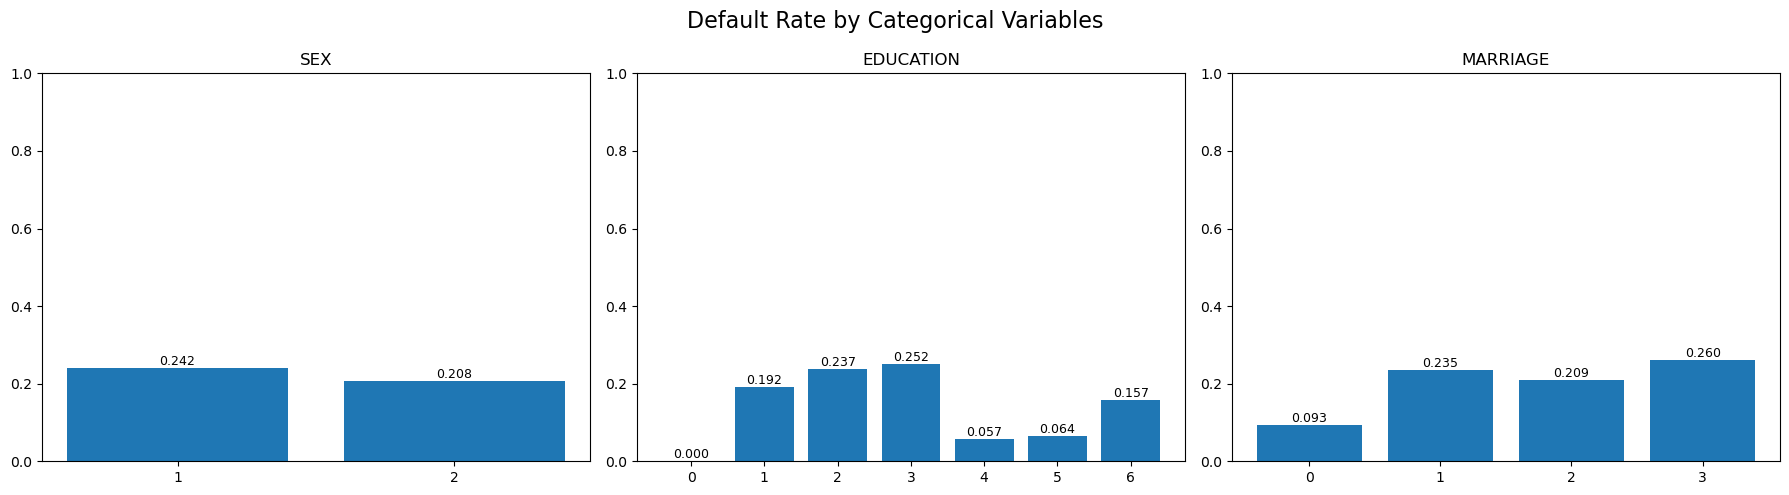

In [8]:
# Examine how default rate varies across repayment status levels
repayment_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

fig1, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(repayment_cols):
    
    # Compute mean default rate per category
    default_rate = df.groupby(col)[target_column].mean().sort_index()
    
    bars = axes[i].bar(default_rate.index.astype(str),
                       default_rate.values)
    
    axes[i].set_title(col)
    axes[i].set_ylim(0,1)

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     height,
                     f"{height:.3f}",
                     ha='center',
                     va='bottom',
                     fontsize=9)

fig1.suptitle("Default Rate by Repayment Status", fontsize=16)
plt.tight_layout()
plt.show()


# Examine default rate across categorical variables
categorical_vars = ["SEX", "EDUCATION", "MARRIAGE"]

fig2, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(categorical_vars):
    
    # Compute mean default rate per category
    default_rate = df.groupby(col)[target_column].mean().sort_index()
    
    bars = axes[i].bar(default_rate.index.astype(str),
                       default_rate.values)
    
    axes[i].set_title(col)
    axes[i].set_ylim(0,1)

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     height,
                     f"{height:.3f}",
                     ha='center',
                     va='bottom',
                     fontsize=9)

fig2.suptitle("Default Rate by Categorical Variables", fontsize=16)
plt.tight_layout()
plt.show()

Default rates vary substantially across repayment status categories.

PAY_0 exhibits a monotonic increase in default risk. Clients with on-time repayment (PAY_0 = 0) have a default rate of 12.8%, compared with 33.9% for a one-month delay and over 69% for delays of two months or more. 

Other repayment variables (PAY_2 to PAY_6) show similar patterns.

This sharp increase highlights the strong predictive power of recent repayment behaviour.

However, PAY_0 reflects very recent repayment behaviour. Since it is closely tied to the default month, it is important to consider whether this information would realistically be available at the time the prediction is made. This will be discussed later as a modelling limitation

Default rates also vary across demographic categories, suggesting potential demographic differences in risk profiles.

### 2.2 Missingness and Data Quality

#### 2.2.1 Missing Value Check
Basic data quality checks are performed to identify missing values and inspect summary statistics.

In [10]:
# Check for missing values
missing_summary = df.isnull().sum()
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [11]:
# Generate summary statistics of numerical variables
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


No missing values are observed in the dataset.
Variables are on different numerical scales.

#### 2.2.2 Categorical Variable Inspection

Although SEX, EDUCATION, and MARRIAGE are encoded numerically, they represent categorical variables.

Value counts are examined to verify category validity and detect undocumented codes.

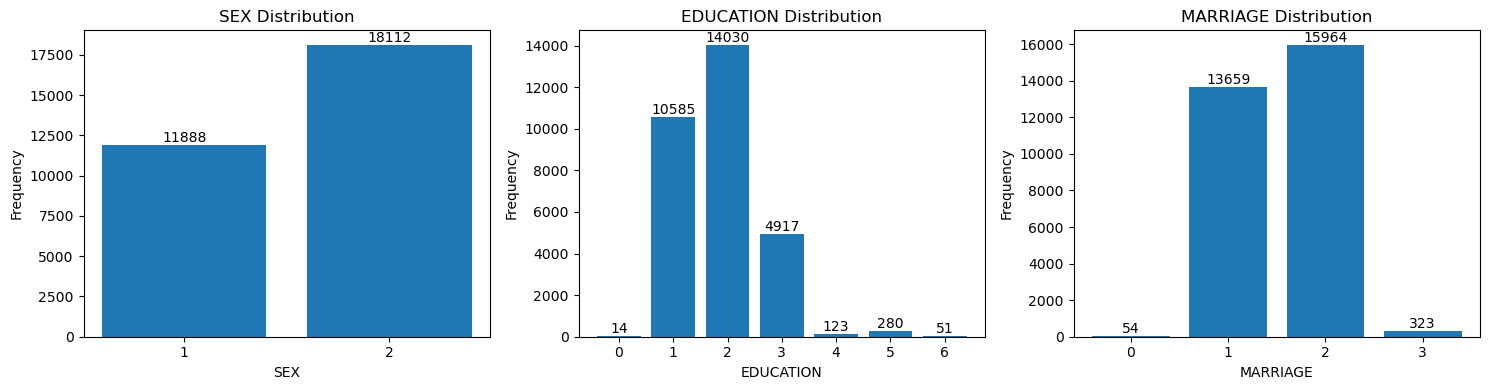

In [12]:
# Visualise distribution of key categorical variables
cols = ["SEX", "EDUCATION", "MARRIAGE"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cols):
    
    # Count frequency of each category
    counts = df[col].value_counts().sort_index()

    x = [int(v) for v in counts.index.tolist()]
    y = counts.values

    bars = ax.bar(x, y)

    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x])

    # Annotate bars with counts
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

The categorical summaries reveal that:

- SEX contains two valid categories (1 and 2), consistent with documentation.
- EDUCATION includes categories 0 and 5–6, which are undocumented or labeled as “unknown”. 
- MARRIAGE includes category 0, which is not described in the Kaggle dataset description.

These undocumented codes likely represent missing or miscellaneous categories. 
They are retained at this stage but will be handled carefully during preprocessing.

This confirms that categorical variables require proper encoding before modelling.

#### 2.2.3 Negative Billing Amount Investigation

The summary statistics indicate that billing amount variables contain negative values.
To determine whether these values indicate data quality issues or reflect valid financial behaviour, the number and proportion of negative observations are calculated for each billing month.

In [13]:
# Identify negative values in billing variables
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]

# Count number and proportion of negative amounts
neg_counts = (df[bill_cols] < 0).sum().sort_values(ascending=False)
neg_props = (df[bill_cols] < 0).mean().sort_values(ascending=False)

neg_summary = pd.DataFrame({
    "negative_count": neg_counts,
    "negative_proportion": neg_props
})

display(neg_summary)

# Inspect example rows with negative billing amounts
neg_rows = df[df[bill_cols].lt(0).any(axis=1)][bill_cols + [target_column]].head(10)
display(neg_rows)

,negative_count,negative_proportion
BILL_AMT6,688,0.022933
BILL_AMT4,675,0.022500
BILL_AMT2,669,0.022300
BILL_AMT3,655,0.021833
BILL_AMT5,655,0.021833
BILL_AMT1,590,0.019667


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,default.payment.next.month
7,11876.0,380.0,601.0,221.0,-159.0,567.0,0
26,-109.0,-425.0,259.0,-57.0,127.0,-189.0,1
35,30265.0,-131.0,-527.0,-923.0,-1488.0,-1884.0,0
37,15054.0,9806.0,11068.0,6026.0,-28335.0,18660.0,0
56,16386.0,15793.0,8441.0,7142.0,-679.0,8321.0,0
68,-190.0,-9850.0,-9850.0,10311.0,10161.0,7319.0,0
72,9076.0,5787.0,-684.0,5247.0,3848.0,3151.0,0
92,-2000.0,5555.0,0.0,0.0,0.0,0.0,0
101,-81.0,-303.0,32475.0,32891.0,33564.0,34056.0,0
109,-103.0,-103.0,-103.0,-103.0,-103.0,-103.0,0


The proportion of negative values is approximately 2% across all billing months. 
Negative values appear consistently across multiple periods rather than as isolated anomalies.

These observations suggest that negative billing amounts likely reflect legitimate financial adjustments (e.g., refunds or credits), rather than data entry errors.

At this stage, negative billing amounts are retained. They are treated as valid financial behaviour.

### 2.3 Correlation Analysis and Leakage Risk

A correlation heatmap is generated to inspect potential multicollinearity among predictors.

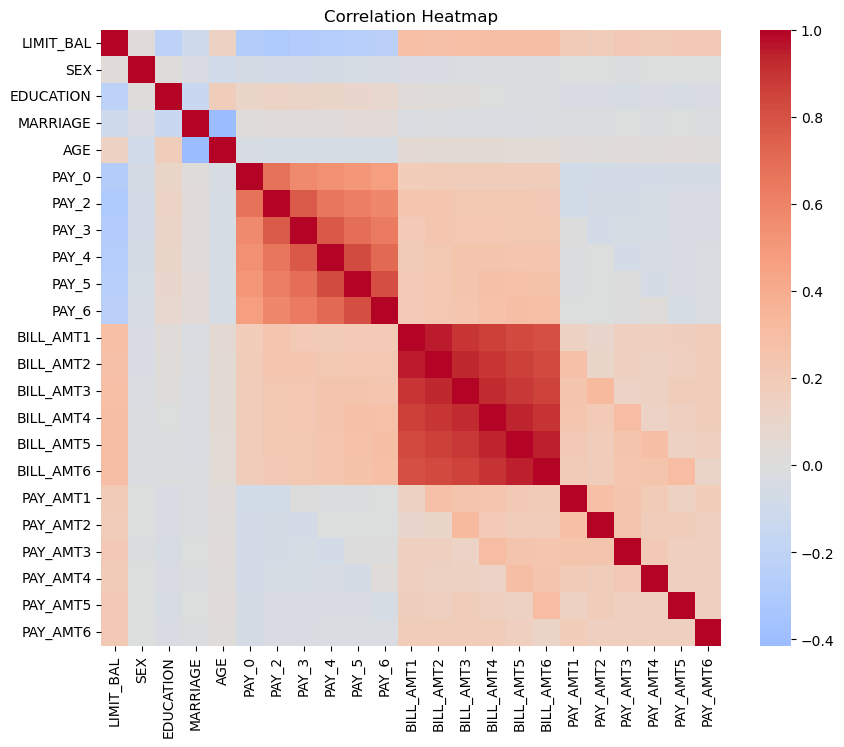

In [15]:
# Compute correlation matrix (exclude ID and target)
corr = df.drop(columns=["ID", target_column]).corr()

# Visualise feature correlations
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Strong correlations are observed among temporally related variables, particularly:
- Payment status variables (PAY_0–PAY_6)
- Billing amount variables (BILL_AMT1–BILL_AMT6)

These correlations are expected given the sequential nature of monthly financial records.  
At this stage, no variables are removed. Multicollinearity may affect coefficient stability in linear models. Tree-based models are not directly affected by multicollinearity.

#### Leakage Risk Assessment

The target variable represents default in the following month (October 2005).

Repayment status variables (PAY_0–PAY_6) reflect behaviour from April to September 2005.  
In particular, PAY_0 captures repayment status in September 2005, immediately preceding the prediction month.

This temporal proximity provides strong predictive signal. While this does not constitute direct data leakage, it creates a short-horizon prediction setting.

This modelling assumption will be acknowledged as a limitation in the final discussion.

### 2.4 Outlier Inspection
Boxplots are used to visualise distribution shape and potential extreme observations. I mainly focus on monetary variables (LIMIT_BAL, BILL_AMT, PAY_AMT), as extreme values in financial amounts may influence model behaviour, particularly for linear models.

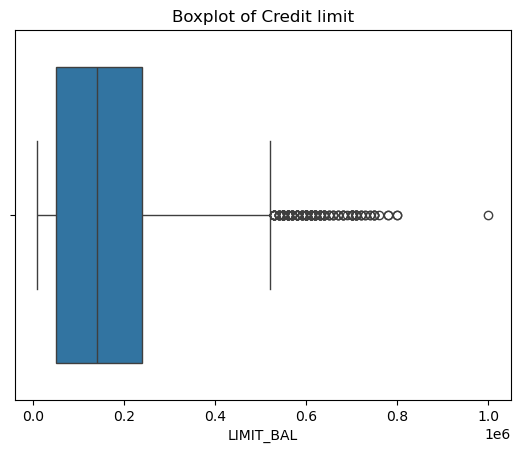

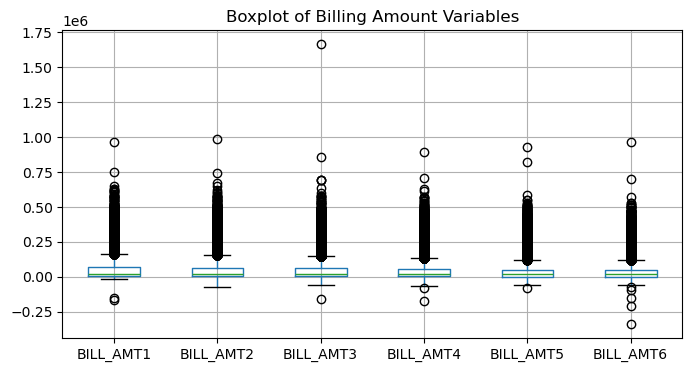

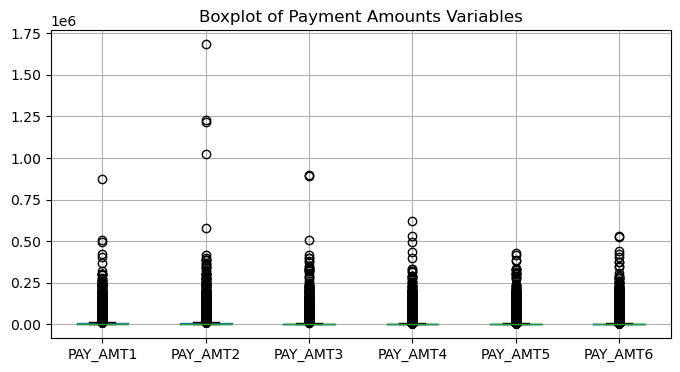

In [13]:
# Draw a boxplt of Billing Amount
sns.boxplot(x=df["LIMIT_BAL"])
plt.title("Boxplot of Credit limit")
plt.show()

# Draw a boxplt of Billing Amount
df[[f"BILL_AMT{i}" for i in range(1,7)]].boxplot(figsize=(8,4))
plt.title("Boxplot of Billing Amount Variables")
plt.show()

# Draw a boxplt of Billing Amount
df[[f"PAY_AMT{i}" for i in range(1,7)]].boxplot(figsize=(8,4))
plt.title("Boxplot of Payment Amounts Variables")
plt.show()

The monetary variables show clear right-skewed distributions with several high-value observations.

Since large amounts are possible in credit card data, extreme values are retained. They do not appear to be data entry errors.

Due to scale differences, feature scaling will be applied for linear models. Tree-based models are less affected by this distribution.

### 2.5 Key EDA Observations

The exploratory analysis yields the following key observations:

- No missing values are detected in the dataset.
- The positive class proportion (~22%) indicates moderate class imbalance. This reinforces the earlier decision to prioritise ranking-based evaluation metrics over accuracy.
- Repayment status variables show a strong relationship with default probability. Clients with higher delinquency levels tend to have higher default rates. This suggests that recent repayment behaviour is likely to be among the most predictive features.
- Undocumented category codes are observed in some categorical variables, highlighting the need for proper encoding prior to modelling.
- Variables are measured on substantially different numerical scales, supporting the use of feature scaling for linear models.
- Strong correlations are observed among temporally related variables (e.g., PAY_0–PAY_6 and BILL_AMT1–BILL_AMT6), which is expected given the sequential nature of financial records.
- No direct future information leakage is observed. However, the temporal proximity of repayment status variables (particularly PAY_0) to the prediction window is acknowledged as a modelling limitation and will be discussed when interpreting model performance.
- Given the heavy right-skewness, linear models may be sensitive to extreme values, while tree-based models are more robust.

### 2.6 Agent Touchpoint: EDA Validation  
To validate the completeness and methodological soundness of the exploratory data analysis, Claude Code was consulted as a structured reviewer.

**Prompt to Claude Code:**

> I have completed EDA including target distribution analysis, missingness checks, correlation heatmap, and outlier inspection.  
> Please review whether the methodology is sufficient for a binary classification task and identify any missing components.

### Agent Feedback (Summary)

The agent identified the following potential gaps:

- Absence of class-conditional analysis (feature distributions stratified by the target variable).  
- Limited exploration of categorical variables encoded numerically.
- The need to explicitly discuss the temporal proximity of repayment status variables (e.g., PAY_0) relative to the prediction target.  

### Evaluation and Decision  

- **Class-conditional analysis — Adopted.**  
   This was accepted because examining feature behaviour across default and non-default groups helps assess discriminatory power. Default rates were therefore analysed across key predictors such as repayment status and selected categorical variables.

- **Inspection of categorical variables — Adopted.**  
   This was accepted to verify the validity of integer-coded categories and detect undocumented values. Value counts were examined for `SEX`, `EDUCATION`, and `MARRIAGE` to ensure appropriate treatment during preprocessing.

- **Explicit discussion of temporal proximity (PAY_0) — Adopted.**  
   This was accepted because repayment status immediately preceding the prediction month may inflate predictive strength. The temporal relationship was therefore documented and acknowledged as a modelling limitation rather than direct leakage.

Following these revisions, no evidence of direct future information leakage was identified.

## Section 3. Prepare the Data

### 3.1 Agent Touchpoint: Cleaning / Split Verification

To ensure that the data preparation process was methodologically sound, Claude Code was consulted before finalising the preprocessing design.

**Prompt to Claude Code:**

>I am preparing data for a credit default classification task.
There are no missing values.
Features include numeric variables and integer-coded categorical variables.
I plan to:
>1) Perform a stratified train/test split (80/20),
>2) Use StandardScaler for Logistic Regression,
>3) Use Random Forest without scaling,
>4) Avoid separate validation set and instead apply cross-validation on the training set.  

>Please review whether this preparation plan is appropriate and identify potential leakage or preprocessing issues.

**Agent Suggestions**

The agent recommended:

- Using a strict train/test split with stratification to preserve class imbalance.
- Ensuring preprocessing steps (e.g. scaling) are fitted only on the training data.
- Considering explicit categorical encoding for variables such as SEX, EDUCATION, and MARRIAGE.
- Implementing validation checks to confirm no target leakage and no overlap between train and test sets.

**Evaluation and Decision**

After review:

- **Stratified train/test split — Adopted.**  
   Accepted to preserve the ~22% default rate across subsets and ensure stable performance estimation.
- **Training-only fitting of preprocessing steps — Adopted.**  
   Accepted to prevent information leakage from the test set. Implemented via `sklearn` Pipelines.
- **Explicit categorical encoding — Adopted.**  
   Accepted to prevent integer-coded categories from being treated as ordinal values. Implemented using `OneHotEncoder`.(Brownlee, 2020)
- **Validation checks for leakage and split integrity — Adopted.**  
   Accepted to ensure methodological transparency and confirm that no target leakage occurred.  
   Data validation checks includes:
  1. Verification of disjoint train/test indices
  2. Confirmation of class distribution preservation
  3. Explicit check that the target variable is excluded from feature matrices

### 3.2 Train/Test Split Discipline

A single train/test split is used, and model selection/tuning will be performed using cross-validation on the training set only.

- The test set is held out and used only once for final evaluation.
- A stratified split is applied to preserve the target class proportion (~22% default rate).
- The ID column is removed because it is an identifier rather than a predictive feature.


In [18]:
# Remove ID column (not predictive)
X = df.drop(columns=["ID", target_column])
y = df[target_column]

# Single train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
     X, y,
     test_size=0.2,  # 20% test set
     random_state=42,# reproducibility
     stratify=y      # Preserves class distribution
)
    
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Overall default rate: {y.mean():.3f}")
print(f"Train default rate:   {y_train.mean():.3f}")
print(f"Test default rate:    {y_test.mean():.3f}")

Train shape: (24000, 23) | Test shape: (6000, 23)
Overall default rate: 0.221
Train default rate:   0.221
Test default rate:    0.221


### 3.3 Preprocessing Pipeline

To prevent data leakage and ensure reproducibility, preprocessing is implemented using a unified sklearn `ColumnTransformer`.

Features are divided into:

- Numeric variables: scaled using `StandardScaler` for Logistic Regression, and passed through without scaling for Random Forest
- Categorical variables (SEX, EDUCATION, MARRIAGE): encoded using `OneHotEncoder`

This design ensures:

- Proper handling of nominal categorical variables
- A fair comparison between a linear baseline (with scaling) and a tree-based model (no scaling required)
- Strict training-only fitting of transformations via Pipeline

In [19]:
# Define categorical and numeric columns
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# Preprocessor for Logistic Regression (needs scaling)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocessor for Random Forest (scaling not needed)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(random_state=42))
])

### 3.4 Data Validation Checks

Validation checks are performed to demonstrate split discipline and reduce leakage risk:

1) Train/test sets are disjoint (no index overlap).  
2) Stratification preserved class balance across splits.  
3) The target column is excluded from the feature matrix.  

These checks provide an auditable record of data preparation integrity.

In [20]:
# Check 1: Disjoint splits (no data leakage)
# Ensure no overlap between train and test indices
train_indices = set(X_train.index)
test_indices = set(X_test.index)

assert train_indices.isdisjoint(test_indices), "Train/test overlap detected!"
print(f"✓ Splits are disjoint: {len(train_indices)} train, {len(test_indices)} test")

# Check 2: Class balance preservation
# Verify stratification worked
train_pos_rate = y_train.mean()
test_pos_rate = y_test.mean()
overall_pos_rate = y.mean()

print(f"Overall positive rate: {overall_pos_rate:.2%}")
print(f"Train positive rate: {train_pos_rate:.2%}")
print(f"Test positive rate: {test_pos_rate:.2%}")

assert abs(train_pos_rate - overall_pos_rate) < 0.01, "Class imbalance in train split!"
assert abs(test_pos_rate - overall_pos_rate) < 0.01, "Class imbalance in test split!"
print("✓ Class balance preserved across splits")

# Check 3: No target leakage in features
# Ensure target column not in feature set
assert target_column not in X_train.columns, "Target leaked into features!"
assert target_column not in X_test.columns, "Target leaked into features!"
print("✓ Target variable excluded from feature matrix")

✓ Splits are disjoint: 24000 train, 6000 test
Overall positive rate: 22.12%
Train positive rate: 22.12%
Test positive rate: 22.12%
✓ Class balance preserved across splits
✓ Target variable excluded from feature matrix


## Section 4. Explore Different Models and Shortlist the Best Ones

### 4.1 Agent Touchpoint: Model Suggestion & Verification

Claude Code was consulted prior to model experimentation to review the proposed modelling strategy.

**Prompt to Claude Code:**

> I plan to compare Logistic Regression (baseline) and Random Forest (modern model) for credit default prediction (~22% positive class).
> I will use stratified cross-validation on the training set only.
> Please review whether this modelling strategy is methodologically sound and identify potential preprocessing or evaluation risks.

### Agent Feedback (Summary)

The agent indicated that:

- Logistic Regression is appropriate as a transparent baseline model.
- Random Forest provides a suitable non-linear benchmark.
- Categorical variables require careful handling in Logistic Regression.
- Class imbalance should be addressed (e.g., class_weight).
- Additional boosting models such as XGBoost could be considered.

### Evaluation and Decision

- **Logistic Regression as baseline — Adopted**  
This aligns with the objective of establishing a transparent linear benchmark for comparison against a non-linear model.

- **Random Forest as non-linear benchmark — Adopted**  
Random Forest can capture interactions and non-linear relationships that Logistic Regression may miss, making it suitable for credit risk prediction.

- **Careful handling of categorical variables — Adopted**  
This recommendation was already incorporated in the preprocessing pipeline established in Section 3.

- **Address class imbalance using class_weight — Partially adopted**  
The suggestion was incorporated into model configurations and later evaluated during hyperparameter tuning to assess its impact on minority-class performance.

- **Introduce boosting models such as XGBoost — Not adopted**  
The objective of this section is to compare a linear baseline with a tree-based ensemble under a controlled evaluation protocol. Random Forest already provides a strong non-linear benchmark. Adding XGBoost would likely yield incremental performance differences (Bentéjac, Csörgő and Martínez-Muñoz, 2021) without materially improving conceptual contrast.

All model configurations were evaluated using identical stratified cross-validation procedures on the training data to ensure comparability and avoid selection bias.

### 4.2 Baseline Model — Logistic Regression

Logistic Regression is evaluated as the linear baseline model.

Stratified 5-fold cross-validation is applied on the training set.
ROC-AUC is used as the evaluation metric.

In [21]:
# Define stratified 5-fold cross-validation (with shuffling)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Logistic Regression using ROC-AUC
lr_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

# Display cross-validation performance
print("Logistic Regression CV ROC-AUC scores:", lr_scores)
print("Mean ROC-AUC:", lr_scores.mean())
print("Std ROC-AUC:", lr_scores.std())

Logistic Regression CV ROC-AUC scores: [0.74230712 0.72976626 0.70958719 0.72016542 0.73368867]
Mean ROC-AUC: 0.7271029330854999
Std ROC-AUC: 0.011283288798584095


### 4.3 Modern Model — Random Forest

Random Forest is evaluated as a non-linear ensemble benchmark.

The same cross-validation protocol is used to ensure comparability.

In [23]:
# Evaluate Random Forest using ROC-AUC
rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

# Display cross-validation performance
print("Random Forest CV ROC-AUC scores:", rf_scores)
print("Mean ROC-AUC:", rf_scores.mean())
print("Std ROC-AUC:", rf_scores.std())

Random Forest CV ROC-AUC scores: [0.76783157 0.77168609 0.75962389 0.76202416 0.76816837]
Mean ROC-AUC: 0.7658668182686792
Std ROC-AUC: 0.004399124611871742


### 4.4 Model Comparison and Shortlisting Decision

Logistic Regression achieved a mean ROC-AUC of 0.727 (std = 0.011).

Random Forest achieved a higher mean ROC-AUC of 0.766 (std = 0.004), and showed more stable performance across folds.

Cross-validation is performed on the training set only; the held-out test set is not used in this section.

The performance gap suggests that a non-linear model captures additional structure beyond a linear decision boundary.

Random Forest is therefore selected for further hyperparameter tuning.

## Section 5. Fine-Tune and Evaluate

### 5.1 Hyperparameter Tuning Strategy
To find the optimal configuration for the shortlisted Random Forest model, I implemented a structured grid search strategy with the following constraints:

**Search Method**: `GridSearchCV` with 5-fold stratified cross-validation on the training set. Performance was reported as mean and standard deviation of ROC-AUC across folds.

**Optimization Metric**: ROC-AUC, selected to maximize the model's ability to effectively rank high-risk clients above low-risk ones.

**Imbalance Handling**: Although SMOTE was considered, it was not adopted due to potential data leakage concerns within cross-validation. Instead, class imbalance was addressed by tuning the `class_weight` parameter in the Random Forest model, which adjusts misclassification penalties without modifying the original data distribution.

**Search Space**: Focused on key structural parameters including `n_estimators`, `max_depth`, `min_samples_split`, and `class_weight`.

In [19]:
# FIX 1: Use 'model__' prefix for parameter keys. 
# In an sklearn Pipeline, parameters of the nested estimator must be accessed 
# using the step name followed by double underscores.
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', 'balanced_subsample']  # Address class imbalance
}

# FIX 2: Use 'rf_pipeline' defined in Section 3.3 as the estimator.
# This ensures that raw data is automatically processed by the ColumnTransformer
# (One-Hot Encoding for categorical variables and passthrough for numeric variables) before reaching the model.
# FIX 3: Use the explicit cv object (StratifiedKFold) defined in Section 4.2.
# This ensures consistency in data splitting between the baseline model and the grid search process, maintaining a fair comparison benchmark.
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,               
    scoring='roc_auc',  # Optimize for ROC-AUC metric
    n_jobs=-1,          # Use all available CPU cores for parallel processing
    verbose=2,          # Display progress logs
    return_train_score=True
)

print("\nStarting Grid Search...")
# FIX 4: Calculate total configurations separately to avoid the unterminated 
# f-string syntax error observed in the previous version.
total_configs = (len(param_grid['model__n_estimators']) * len(param_grid['model__max_depth']) * len(param_grid['model__min_samples_split']) * len(param_grid['model__class_weight']))

print(f"Total configurations to evaluate: {total_configs}")
print(f"Using 5-fold CV on training set (n={len(X_train)})\n")

# Execute grid search on the training set only to prevent leakage from the test set
grid_search.fit(X_train, y_train)
# Sanity check: best estimator exists and we did not refit on test
assert hasattr(grid_search, "best_estimator_")

# ------------------------------------------------------------------------------
# RESULTS SUMMARY
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS (selected via CV on training set):")
print("=" * 60)
# Print the best parameters found by GridSearchCV
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV ROC-AUC (training set score): {grid_search.best_score_:.4f}")

# ------------------------------------------------------------------------------
# TOP 5 CONFIGURATIONS DISPLAY
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 5 CONFIGURATIONS:")
print("=" * 60)
cv_results = grid_search.cv_results_
# Sort configurations based on mean test score in descending order
top_5_indices = np.argsort(cv_results['mean_test_score'])[-5:][::-1]

for rank, idx in enumerate(top_5_indices, 1):
    # FIX 5: Explicitly extract variables before printing to resolve the 
    # unterminated f-string literal error.
    mean_auc = cv_results['mean_test_score'][idx]
    std_auc = cv_results['std_test_score'][idx]
    params = cv_results['params'][idx]
    
    print(f"\nRank {rank}:")
    print(f"  Mean CV ROC-AUC: {mean_auc:.4f} (+/- {std_auc:.4f})")
    print(f"  Params: {params}")


Starting Grid Search...
Total configurations to evaluate: 72
Using 5-fold CV on training set (n=24000)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

BEST HYPERPARAMETERS (selected via CV on training set):
  model__class_weight: balanced_subsample
  model__max_depth: 10
  model__min_samples_split: 10
  model__n_estimators: 300

Best CV ROC-AUC (training set score): 0.7798

TOP 5 CONFIGURATIONS:

Rank 1:
  Mean CV ROC-AUC: 0.7798 (+/- 0.0059)
  Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Rank 2:
  Mean CV ROC-AUC: 0.7798 (+/- 0.0059)
  Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Rank 3:
  Mean CV ROC-AUC: 0.7798 (+/- 0.0054)
  Params: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Rank 4:
  Mean CV ROC-AUC: 0.

The best configuration achieved a mean CV ROC-AUC of 0.7798, compared with 0.766 for the baseline Random Forest reported in Section 4. This improvement indicates that hyperparameter tuning within the same model class enhances ranking performance.

The selected parameters (`max_depth = 10`, `min_samples_split = 10`) suggest that limiting tree depth and requiring larger splits improves generalisation by reducing unnecessary model complexity. The selection of `balanced_subsample` further indicates that internal class reweighting is beneficial under moderate imbalance.

The top configurations exhibit very similar ROC-AUC values with low standard deviations across folds, indicating that performance is stable and not driven by a single parameter combination.

### 5.2 Final Test Set Evaluation

After identifying the best hyperparameters via cross-validation (Best CV ROC-AUC: 0.7798), the model was retrained on the full training set and evaluated once on the held-out test set to obtain an unbiased estimate of out-of-sample performance.

ROC-AUC was selected as the primary evaluation metric to assess ranking performance. AUPRC was reported as a complementary metric given the class imbalance. 

The difference between cross-validation performance and test performance was also examined to assess potential overfitting.

In [20]:
print("\n" + "=" * 60)
print("SECTION 5.2: FINAL TEST SET EVALUATION")
print("=" * 60)

# Extract best model from grid search
best_rf = grid_search.best_estimator_

# Predict on test set
y_test_pred_proba = best_rf.predict_proba(X_test)[:, 1]
y_test_pred = best_rf.predict(X_test)

# Threshold-independent metrics
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
test_auprc = average_precision_score(y_test, y_test_pred_proba)

print("\nThreshold-Independent Metrics:")
print(f"  ROC-AUC:  {test_roc_auc:.4f}")
print(f"  AUPRC:    {test_auprc:.4f}")

# Threshold-dependent metrics (at default threshold=0.5)
print("\n" + "-" * 60)
print("Classification Report (threshold=0.5):")
print("-" * 60)
print(classification_report(y_test, y_test_pred, 
                            target_names=['No Default (0)', 'Default (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print(f"\n  True Negatives:  {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives:  {cm[1,1]}")

# Interpretation
print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)

# FIX 6: Pre-calculate interpretation logic (ability and overfit status) into variables. 
# This avoids complex, multi-line nested ternary expressions within f-strings, which triggered 'unterminated f-string literal' SyntaxErrors in the agent's initial version.
ability_status = 'strong' if test_roc_auc > 0.75 else 'moderate'
score_gap = abs(grid_search.best_score_ - test_roc_auc)
overfit_status = 'minimal' if score_gap < 0.02 else 'some'

# FIX 7: Use the pre-calculated variables in single-line f-strings. 
# This resolves the fatal SyntaxErrors from the agent code where the print 
print(f"The tuned Random Forest model achieves ROC-AUC = {test_roc_auc:.4f} on the held-out test set.")
print(f"This indicates {ability_status} discriminatory ability between default and non-default clients.")
print(f"\nThe gap between CV score ({grid_search.best_score_:.4f}) and test score ({test_roc_auc:.4f}) is {score_gap:.4f},")
print(f"suggesting {overfit_status} overfitting.")


SECTION 5.2: FINAL TEST SET EVALUATION

Threshold-Independent Metrics:
  ROC-AUC:  0.7747
  AUPRC:    0.5486

------------------------------------------------------------
Classification Report (threshold=0.5):
------------------------------------------------------------
                precision    recall  f1-score   support

No Default (0)       0.87      0.85      0.86      4673
   Default (1)       0.52      0.57      0.54      1327

      accuracy                           0.79      6000
     macro avg       0.70      0.71      0.70      6000
  weighted avg       0.80      0.79      0.79      6000


Confusion Matrix:
[[3971  702]
 [ 570  757]]

  True Negatives:  3971
  False Positives: 702
  False Negatives: 570
  True Positives:  757

INTERPRETATION:
The tuned Random Forest model achieves ROC-AUC = 0.7747 on the held-out test set.
This indicates strong discriminatory ability between default and non-default clients.

The gap between CV score (0.7798) and test score (0.7747) is 0.

**Interpretation of Results**

- Discriminatory Power: The tuned Random Forest model achieves an ROC-AUC of 0.7747 on the held-out test set, indicating solid discriminatory ability between default and non-default clients. The AUPRC of 0.5486 further supports stable ranking performance under class imbalance.

- Overfitting Assessment: The marginal gap (0.0052) between the cross-validation score and the test score suggests that overfitting is minimal. This confirms that the tuned configuration maintains controlled model complexity.

- Recall vs. Precision: At the default threshold of 0.5, the model achieves Recall = 0.57 and Precision = 0.52 for the default class. This indicates that while more than half of actual defaults are captured, a substantial portion of high-risk clients remain undetected.

### 5.3 Threshold and Error Analysis
The default classification threshold of 0.5 may not align with the specific risk appetite of a financial institution. In credit scoring, the cost of a False Negative (failing to predict a default) often outweighs the opportunity cost of a False Positive (wrongfully denying credit).

To determine the most appropriate operational threshold, this section evaluates the model's performance across a range of values using the Precision-Recall curve and ROC curve.

✅ Auto-saved: /Users/jubbie21424/Documents/MSIN0097 Predictive Analytics/Individual/credit-default-project/output/figure_8.png


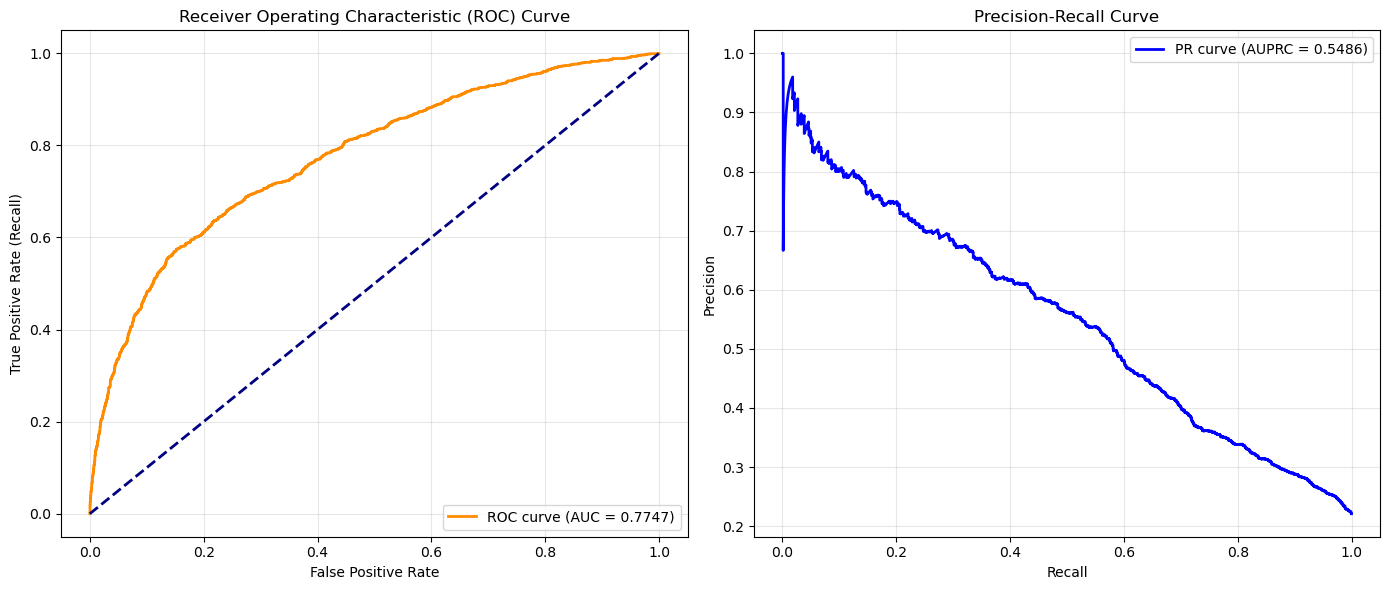

THRESHOLD COMPARISON TABLE
Threshold    | Recall     | Precision  | F1-Score  
------------------------------------------------------------
0.2          | 0.9827     | 0.2396     | 0.3852    
0.3          | 0.8674     | 0.3023     | 0.4484    
0.4          | 0.6948     | 0.4069     | 0.5132    
0.5          | 0.5705     | 0.5188     | 0.5434    
------------------------------------------------------------
Note: Lowering the threshold increases Recall (catching more defaults) 
but decreases Precision (increasing false alarms).


In [25]:
# 1. Calculate Precision-Recall and ROC curves
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_pred_proba)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)

# 2. Plotting the curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Precision-Recall Curve
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUPRC = {test_auprc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Threshold Comparison Table
print("=" * 60)
print("THRESHOLD COMPARISON TABLE")
print("=" * 60)
print(f"{'Threshold':<12} | {'Recall':<10} | {'Precision':<10} | {'F1-Score':<10}")
print("-" * 60)

for t in [0.2, 0.3, 0.4, 0.5]:
    y_t = (y_test_pred_proba >= t).astype(int)
    report = classification_report(y_test, y_t, output_dict=True)['1']
    print(f"{t:<12} | {report['recall']:<10.4f} | {report['precision']:<10.4f} | {report['f1-score']:<10.4f}")

print("-" * 60)
print("Note: Lowering the threshold increases Recall (catching more defaults) \nbut decreases Precision (increasing false alarms).")

**Threshold Optimization Summary**

The default threshold of 0.5 achieves Recall = 0.5705 and Precision = 0.5188, resulting in the highest F1-score (0.5434) among the evaluated thresholds.

- **Trade-off Analysis**: Lowering the threshold to 0.4 increases Recall to 0.6948 but reduces Precision to 0.4069. Further reducing the threshold to 0.3 increases Recall to 0.8674; however, Precision declines to 0.3023.

- **Business Impact**: This pattern demonstrates the trade-off between capturing more defaults and increasing false positives. Based on statistical balance between precision and recall, 0.5 is retained as the reference threshold in this study. However, if the cost of missing a defaulter is substantially higher than the cost of a false alarm, a lower threshold such as 0.4 may be operationally preferable. The final threshold selection should therefore be aligned with institutional risk tolerance and cost structure.

### 5.4 Model Understanding and Calibration

### 5.4.1 Feature Importance

Top 15 features by importance:


,feature,importance
2,num__PAY_0,0.236920
3,num__PAY_2,0.109884
4,num__PAY_3,0.073125
5,num__PAY_4,0.051747
0,num__LIMIT_BAL,0.048093
14,num__PAY_AMT1,0.042381
15,num__PAY_AMT2,0.040779
16,num__PAY_AMT3,0.037482
6,num__PAY_5,0.037184
8,num__BILL_AMT1,0.036011


✅ Auto-saved: /Users/jubbie21424/Documents/MSIN0097 Predictive Analytics/Individual/credit-default-project/output/figure_9.png


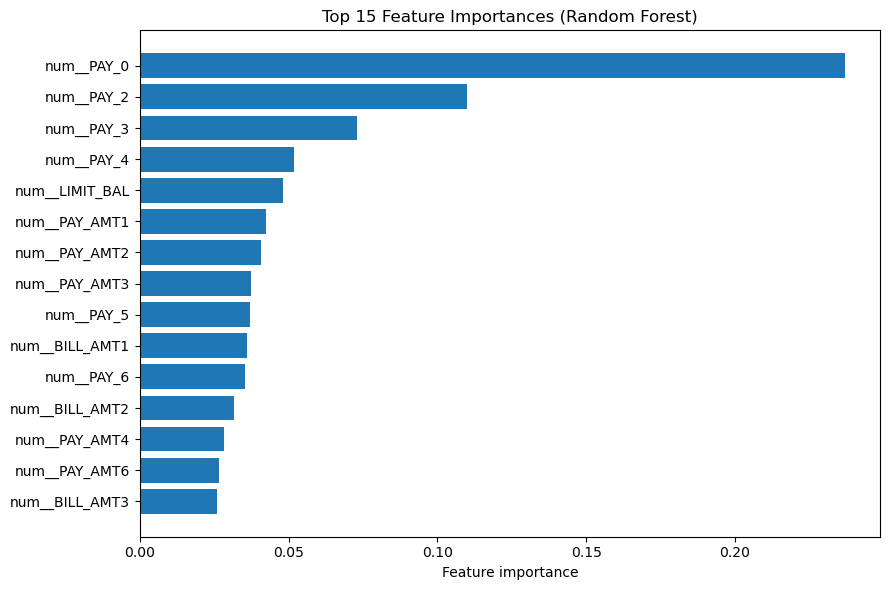

In [26]:
# Extract fitted RF model from the pipeline
rf_model = best_rf.named_steps["model"]

# Extract feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Build importance table
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

# Show top 15
top_k = 15
print(f"Top {top_k} features by importance:")
display(importance_df.head(top_k))

# 4) Plot top 15
plot_df = importance_df.head(top_k).iloc[::-1]  # reverse for horizontal bar
plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

The feature importance results show that recent repayment status variables have the strongest influence on the model. PAY_0 has the highest importance (about 0.237). PAY_2, PAY_3, and PAY_4 also rank near the top.

In Section 2.1.1, default rates increased sharply when repayment status moved from on-time (PAY_0 = 0) to delinquent categories. Although the pattern was not strictly monotonic across all repayment codes, delinquent states showed much higher default rates than on-time repayment.

The importance ranking reflects this observation. The model assigns the largest weight to PAY_0 and other recent delinquency indicators. This indicates that recent repayment behaviour is the main signal used to separate default and non-default clients.

LIMIT_BAL and recent payment and billing variables (PAY_AMT*, BILL_AMT*) also contribute to the prediction. Their importance values are lower than the PAY variables. This suggests that financial capacity and transaction activity add information, but short-term delinquency remains the dominant driver.

### 5.4.2 Calibration
A calibration curve and Brier score are used to assess probability accuracy on the test set.

Brier score (test): 0.1717
✅ Auto-saved: /Users/jubbie21424/Documents/MSIN0097 Predictive Analytics/Individual/credit-default-project/output/figure_10.png


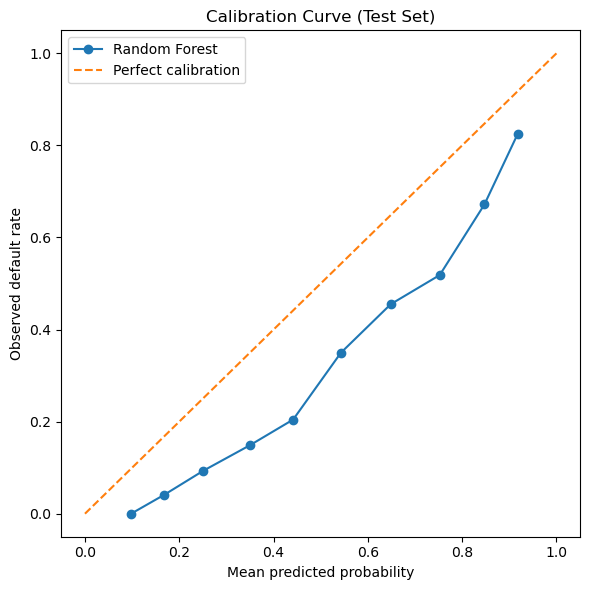

In [27]:
# Calibration curve (10 bins is a common default)
prob_true, prob_pred = calibration_curve(y_test, y_test_pred_proba, n_bins=10, strategy="uniform")

# Brier score (lower is better)
brier = brier_score_loss(y_test, y_test_pred_proba)
print(f"Brier score (test): {brier:.4f}")

# Plot calibration curve
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

The Brier score on the test set is 0.1717, suggesting reasonable but not perfect probability accuracy.  

The curve is close to the diagonal at low probabilities. At higher probabilities, the curve falls below the diagonal. This means the model slightly overestimates default risk at high predicted levels.

As above, it implies that the model ranks clients well, but predicted probabilities are not perfectly calibrated.

### 5.5 Agent Touchpoint: Explicit Agent-Made Mistake and Correction
This section documents the critical review and correction of multiple errors made by the Claude Code during the fine-tuning phase:

**Prompt to Claude Code**

>Provide a complete Python code block for hyperparameter tuning using GridSearchCV to maximize ROC-AUC. Specific requirements included addressing the ~22% class imbalance using SMOTE before running the grid search, and providing code for a final evaluation on the held-out test set.

**Agent Suggestions**

Claude Code flagged a major methodological risk with the initial prompt, correctly identifying that applying SMOTE to the entire training set before cross-validation would cause data leakage and result in overoptimistic scores. It recommended:

- Applying SMOTE only inside each cross-validation fold using a pipeline. Alternatively, using class_weight='balanced' as a simpler and more appropriate approach for moderate imbalance (22%), which was its primary recommendation.

- A standalone code block using RandomForestClassifier with a search space for n_estimators, max_depth, and min_samples_split.

**Evaluation and Decision**

After critical review, the following decisions and corrections were implemented:

- **Methodological Acceptance (SMOTE vs. Class Weight)**: I accepted the agent's warning regarding SMOTE and data leakage. I decided to follow the agent's recommended of using `class_weight='balanced'` within the model parameters, as it effectively handles the 22% imbalance without the added complexity and leakage risks of global oversampling.

- **Correction of Syntax Errors**: The code provided by the agent was unable to execute due to multiple unterminated f-string literals in the logging and interpretation scripts.  
**Correction**: I debugged these syntax errors by manually refactoring the f-strings and ensuring all quotes and line breaks were properly terminated (noted as FIX 4, 5, 6, and 7 in the implementation code).

- **Workflow Incompatibility**: The agent's standalone code ignored the project's `ColumnTransformer` (preprocessor) defined in Section 3.3 and used incorrect parameter naming (lacking the necessary 'model__' prefix).  
**Correction**: I manually re-integrated the preprocessing pipeline and updated the `param_grid` keys (noted as FIX 1 and 2) to ensure the tuning process accurately reflected the full end-to-end model workflow.

- **Experimental Rigor (CV Consistency)**: The agent suggested a default `cv=5`, which lacks shuffling in scikit-learn's default behavior.  
**Correction**: To ensure a strictly fair comparison with the baseline model, I overrode this with the explicit `cv` object(StratifiedKFold) defined in Section 4.2. This ensures identical data splits and consistent shuffling across all benchmarks (noted as FIX 3). 

## Section 6. Present the Final Solution

### 6.1 Final Model and Rationale

The final model is a tuned Random Forest implemented within a Sklearn Pipeline. It achieved a test ROC-AUC of 0.7747 and an AUPRC of 0.5486, showing strong ability to rank higher-risk clients above lower-risk clients under moderate class imbalance.

The model was selected because it consistently outperformed the Logistic Regression baseline during stratified cross-validation (0.766 vs. 0.727) and maintained similar performance on the held-out test set. The small gap between cross-validation performance (0.7798) and test performance (0.7747) indicates stable generalisation rather than overfitting.

This is important for credit risk applications, where the primary objective is to rank clients by short-term default risk  (Kochański, 2024) and apply a business-specific threshold(Denis, no date). Random Forest is also able to capture non-linear patterns in repayment status and transaction behaviour, which a linear model may not fully represent. As repayment variables such as PAY_0 and PAY_2 were found to be highly influential, a non-linear structure is particularly suitable for modelling such risk signals.

### 6.2 Limitations, Risks and Next Steps

**Operational Risk**: At the 0.5 threshold, the model achieves Recall = 0.5705, meaning approximately 43% of defaults remain undetected. Lowering the threshold increases Recall but reduces Precision. The optimal threshold depends on the company’s cost structure and risk tolerance.

**Feature Availability Risk**: Some repayment status variables (e.g., PAY_0) are temporally close to the default event. If these variables are not available at the actual decision time, the model may rely on information that would not be known in practice. This may overstate real-world performance. A feature availability audit is required before deployment.

**Data Constraints**: The dataset is from 2005 and reflects credit behaviour in Taiwan during a relatively stable economic period. Since economic conditions, regulatory standards, and credit assessment practices have evolved, the model may not generalise well to current markets, different regions, or periods of financial stress. Changes in macroeconomic conditions could alter default patterns and weaken the stability of learned relationships.

**Model Calibration**:
Calibration analysis shows that predicted probabilities are not perfectly aligned with observed default rates, particularly at higher probability levels. While ranking performance remains strong, predicted probabilities appear slightly overestimated in the high-risk range. If the model were to be used for decisions that rely directly on probability levels rather than relative risk ranking, further calibration and additional data (e.g., exposure and loss information) would be required.

**Next Steps**: Future work should implement cost-sensitive threshold optimisation, apply probability calibration methods if required, monitor model drift, and evaluate gradient-boosted models such as XGBoost.

### 6.3 Model Card Summary

Category | Details
---|---
**Model Type** | Random Forest Classifier (Optimized via GridSearchCV)
**Intended Use** | Predicting next-month default risk scores to rank clients for short-term credit risk monitoring
**Not Intended For** | Fully automated rejection, long-term pricing, or capital allocation without further validation
**Key Metrics** | Test ROC-AUC = 0.7747; Test AUPRC = 0.5486; Recall (0.5 threshold) = 0.5705
**Data Source & Constraints** | UCI “Default of Credit Card Clients” (Taiwan, 2005); may not generalise to current markets or stressed economic conditions
**Caveats & Risks** | Threshold choice depends on business cost structure; heavy reliance on recent repayment variables (e.g., PAY_0); probabilities are not perfectly fitted at higher risk levels

## Section 7. Reference

Avery, R.B., Calem, P.S. and Canner, G.B. (2004) ‘Consumer credit scoring: do situational circumstances matter?’ Available at: https://www.bis.org/publ/work146.htm

Bentéjac, C., Csörgő, A. and Martínez-Muñoz, G. (2021) ‘A comparative analysis of XGBoost’, *Artificial Intelligence Review*, 54(3), pp. 1937–1967. Available at: https://doi.org/10.1007/s10462-020-09896-5

Brownlee, J. (2020) ‘Ordinal and one-hot encodings for categorical data’, *MachineLearningMastery.com*, 11 June. Available at: https://www.machinelearningmastery.com/one-hot-encoding-for-categorical-data/ (Accessed: 21 February 2026)

Bücker, M. et al. (2020) ‘Transparency, auditability and explainability of machine learning models in credit scoring’. *arXiv preprint*. Available at: https://doi.org/10.48550/arXiv.2009.13384

Default of Credit Card Clients Dataset (2005) *Kaggle*. Available at: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset (Accessed: 20 February 2026)

Denis (no date) *Risk Practitioner Handbook*. Available at: https://risk-practitioner.com/chapter3/chapter3 (Accessed: 20 February 2026)

Kochański, B. (2024) ‘The shape of an ROC curve in the evaluation of credit scoring models’, *Statistics in Transition New Series*, 25(2), pp. 205–218. Available at: https://doi.org/10.59170/stattrans-2024-022

Markov, A., Seleznyova, Z. and Lapshin, V. (2022) ‘Credit scoring methods: latest trends and points to consider’, *The Journal of Finance and Data Science*, 8, pp. 180–201. Available at: https://doi.org/10.1016/j.jfds.2022.07.002

Stratified Sampling in Machine Learning (2025) *GeeksforGeeks*. Available at: https://www.geeksforgeeks.org/machine-learning/stratified-sampling-in-machine-learning/ (Accessed: 21 February 2026)

Yeh, I.-C. and Lien, C. (2009) ‘The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients’, *Expert Systems with Applications*, 36(2, Part 1), pp. 2473–2480. Available at: https://doi.org/10.1016/j.eswa.2007.12.020

## Appendix A. Agent Usage ＆ Decision Register

| Project Phase | Key Agent Contribution | Decision | Rationale / Action Taken |
| :--- | :--- | :--- | :--- |
| **1.5 Metric Selection** | Suggested AUPRC for imbalanced data. | **Modified** | Retained ROC-AUC as primary for industry alignment; added AUPRC as complementary diagnostic. |
| **2.6 EDA Validation** | Identified gaps in class-conditional and temporal analysis. | **Accepted** | Examined default rates by repayment status and selected categorical variables, and documented temporal limitations of PAY variables. |
| **3.1 Preprocessing & Split** | Advised on categorical encoding and strict leakage prevention. | **Accepted** | Implemented OneHotEncoder and sklearn Pipelines to ensure transformations are fitted only on training data and splits are leakage-free. |
| **4.1 Model Selection** | Suggested adding XGBoost and using class weights. | **Modified** | Rejected XGBoost to maintain clear baseline contrast; accepted class weight tuning for Random Forest. |
| **5.5 Fine-Tuning & Error Correction** | Warned about SMOTE leakage risk; suggested default `cv=5`; provided code with syntax and pipeline mapping issues. | **Modified** | Accepted leakage warning and rejected SMOTE before CV; used class weight tuning instead. Overrode with explicit `cv` object (StratifiedKFold) to ensure shuffled splits [FIX 3]. Reintegrated preprocessing pipeline, corrected `model__` prefixes, and fixed f-string errors [FIX 1-2,4-6]. |